In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

fraud = pd.read_csv("../data/raw/Fraud_Data.csv")
fraud.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [3]:
fraud.shape
fraud.info()
fraud.describe()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


,user_id,purchase_value,age,ip_address,class
count,151112.000000,151112.000000,151112.000000,1.511120e+05,151112.000000
mean,200171.040970,36.935372,33.140704,2.152145e+09,0.093646
std,115369.285024,18.322762,8.617733,1.248497e+09,0.291336
min,2.000000,9.000000,18.000000,5.209350e+04,0.000000
25%,100642.500000,22.000000,27.000000,1.085934e+09,0.000000
50%,199958.000000,35.000000,33.000000,2.154770e+09,0.000000
75%,300054.000000,49.000000,39.000000,3.243258e+09,0.000000
max,400000.000000,154.000000,76.000000,4.294850e+09,1.000000


In [4]:
fraud.isnull().sum()
fraud.duplicated().sum()

np.int64(0)

In [2]:
fraud["class"].value_counts()

NameError: name 'fraud' is not defined

In [3]:
import pandas as pd

fraud = pd.read_csv("../data/raw/Fraud_Data.csv")

In [4]:
fraud.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [5]:
fraud["class"].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [6]:
fraud["class"].value_counts(normalize=True) * 100

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

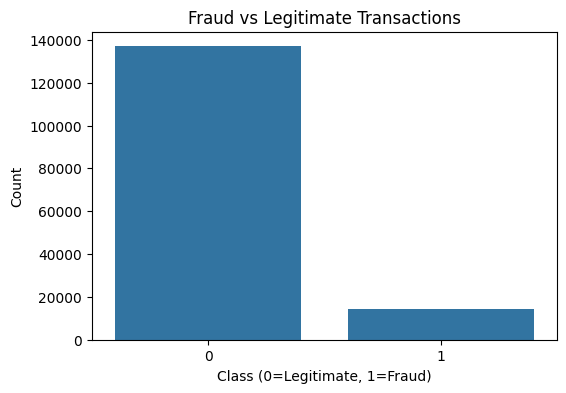

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='class', data=fraud)

plt.title('Fraud vs Legitimate Transactions')
plt.xlabel('Class (0=Legitimate, 1=Fraud)')
plt.ylabel('Count')

plt.show()

In [8]:
plt.savefig("fraud_class_distribution.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [9]:
fraud.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [10]:
fraud.duplicated().sum()

np.int64(0)

In [11]:
fraud["signup_time"] = pd.to_datetime(fraud["signup_time"])
fraud["purchase_time"] = pd.to_datetime(fraud["purchase_time"])

In [12]:
fraud["time_since_signup"] = (
    fraud["purchase_time"] - fraud["signup_time"]
).dt.total_seconds()

fraud["hour_of_day"] = fraud["purchase_time"].dt.hour

fraud["day_of_week"] = fraud["purchase_time"].dt.dayofweek

In [13]:
fraud[
    [
        "time_since_signup",
        "hour_of_day",
        "day_of_week"
    ]
].head()

,time_since_signup,hour_of_day,day_of_week
0,4506682.0,2,5
1,17944.0,1,0
2,1.0,18,3
3,492085.0,13,0
4,4361461.0,18,2


In [14]:
ip = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

In [15]:
ip.head()

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


In [16]:
ip.info()

<class 'pandas.DataFrame'>
RangeIndex: 138846 entries, 0 to 138845
Data columns (total 3 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   lower_bound_ip_address  138846 non-null  float64
 1   upper_bound_ip_address  138846 non-null  int64  
 2   country                 138846 non-null  str    
dtypes: float64(1), int64(1), str(1)
memory usage: 3.2 MB


In [17]:
ip["lower_bound_ip_address"] = (
    ip["lower_bound_ip_address"]
    .astype("int64")
)

ip["upper_bound_ip_address"] = (
    ip["upper_bound_ip_address"]
    .astype("int64")
)

fraud["ip_address"] = (
    fraud["ip_address"]
    .astype("int64")
)

In [18]:
ip.info()

<class 'pandas.DataFrame'>
RangeIndex: 138846 entries, 0 to 138845
Data columns (total 3 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   lower_bound_ip_address  138846 non-null  int64
 1   upper_bound_ip_address  138846 non-null  int64
 2   country                 138846 non-null  str  
dtypes: int64(2), str(1)
memory usage: 3.2 MB


In [19]:
fraud["ip_address"] = fraud["ip_address"].astype("int64")

fraud_sorted = fraud.sort_values("ip_address")

ip_sorted = ip.sort_values(
    "lower_bound_ip_address"
)

fraud_country = pd.merge_asof(
    fraud_sorted,
    ip_sorted,
    left_on="ip_address",
    right_on="lower_bound_ip_address",
    direction="backward"
)

fraud_country = fraud_country[
    fraud_country["ip_address"]
    <= fraud_country["upper_bound_ip_address"]
]

In [20]:
fraud_country[
    ["ip_address", "country"]
].head()

,ip_address,country
634,16778864,Australia
635,16842045,Thailand
636,16843656,China
637,16938732,China
638,16971984,Thailand


In [21]:
fraud_country["country"].nunique()

181

In [22]:
fraud_country["country"].value_counts().head(10)

country
United States        58049
China                12038
Japan                 7306
United Kingdom        4490
Korea Republic of     4162
Germany               3646
France                3161
Canada                2975
Brazil                2961
Italy                 1944
Name: count, dtype: int64

In [23]:
fraud_country["country"].value_counts().head(10)

country
United States        58049
China                12038
Japan                 7306
United Kingdom        4490
Korea Republic of     4162
Germany               3646
France                3161
Canada                2975
Brazil                2961
Italy                 1944
Name: count, dtype: int64

In [24]:
fraud_country.shape

(129146, 17)

In [25]:
country_fraud = (
    fraud_country
    .groupby("country")["class"]
    .mean()
    .sort_values(ascending=False)
)

country_fraud.head(10)

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Name: class, dtype: float64

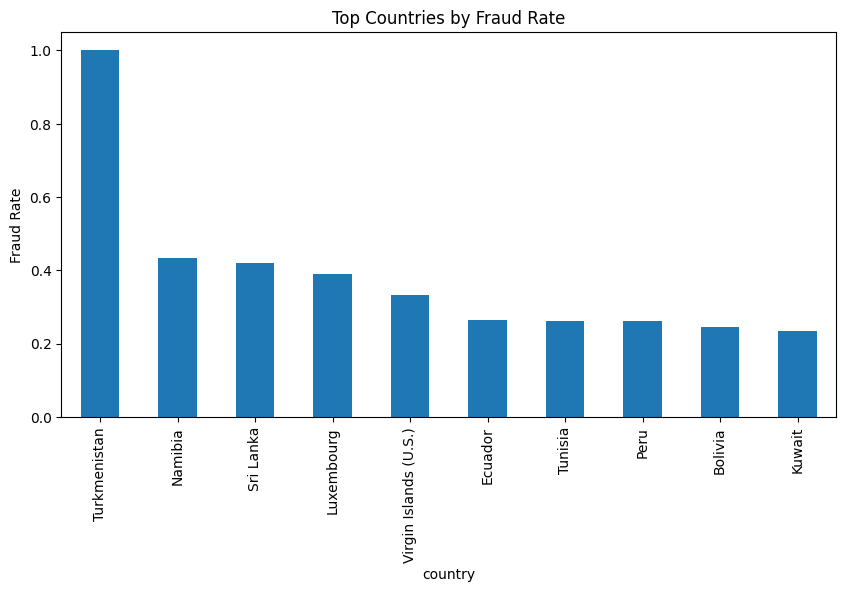

In [26]:
import matplotlib.pyplot as plt

country_fraud.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Countries by Fraud Rate")
plt.ylabel("Fraud Rate")
plt.show()